In [72]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [73]:
df = pd.read_parquet("data/processed/games.parquet")

In [74]:
df['elo_diff'] = df['white_elo'] - df['black_elo']
df[['elo_diff']].head()

,elo_diff
0,-634.0
1,601.0
2,-575.0
3,539.0
4,-558.0


In [75]:
print([col for col in df.columns if "fide" in col])

['white_fide', 'black_fide', 'diff_fide']


In [76]:
df[['white_fide', 'black_fide', 'diff_fide']]

,white_fide,black_fide,diff_fide
0,2387.0,2814.0,-427.0
1,2779.0,NaN,NaN
2,2315.0,NaN,NaN
3,NaN,2307.0,NaN
4,2388.0,2778.0,-390.0
...,...,...,...
4043,2020.0,2074.0,-54.0
4044,NaN,2046.0,NaN
4045,2184.0,1992.0,192.0
4046,2080.0,2004.0,76.0


In [77]:
df['fide_both_nan'] = df['white_fide'].isna() & df['black_fide'].isna()
df['fide_black_nan'] = df['white_fide'].notna() & df['black_fide'].isna()
df['fide_white_nan'] = df['white_fide'].isna() & df['black_fide'].notna()

In [78]:
df['outcome'].value_counts()

outcome
win     1948
loss    1786
draw     314
Name: count, dtype: int64

<Figure size 800x500 with 0 Axes>

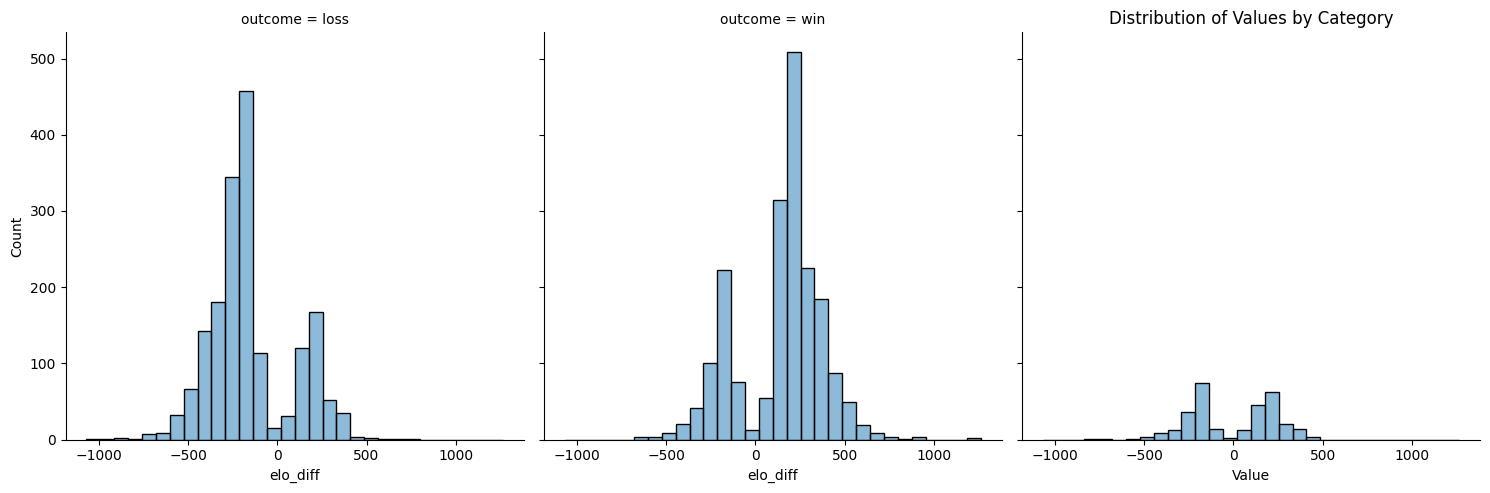

In [79]:
plt.figure(figsize=(8, 5))
sns.displot(
    data=df,
    x='elo_diff',
    col='outcome',
    kde=False,
    bins=30,
    alpha=0.5
)

plt.title('Distribution of Values by Category')
plt.xlabel('Value')
plt.ylabel('Count')
plt.show()

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [85]:
train_mask = df["tournament"].str.contains("february")
test_mask = df["tournament"].str.contains("march")

X = df[['white_elo', 'black_elo', 'elo_diff',
        'fide_both_nan', 'fide_black_nan', 'fide_white_nan',
        'mean_elo']]
y = df[['outcome']]

le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

X_train, y_train = X[train_mask], y_encoded[train_mask]
X_test, y_test = X[test_mask], y_encoded[test_mask]


/home/lornarthebreton/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [89]:
import xgboost as xgb

#X_train, X_test, y_train, y_test = train_test_split(
#    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
#)

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

In [90]:
params = {
    "objective": "multi:softprob",   # use multi:softmax if you just want class labels
    "num_class": num_classes,
    "eval_metric": "mlogloss",       # or 'merror'
    "max_depth": 6,
    "eta": 0.1,                      # learning rate
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 1,
    "seed": 42,
}


In [91]:
evals = [(dtrain, "train"), (dtest, "eval")]

model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=50,
)

[0]	train-mlogloss:0.88312	eval-mlogloss:0.88390
[50]	train-mlogloss:0.53319	eval-mlogloss:0.80770
[68]	train-mlogloss:0.49255	eval-mlogloss:0.82412


In [94]:
y_pred_probs = model.predict(dtest)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_.astype(str)))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6733890801770782

Classification Report:
              precision    recall  f1-score   support

        draw       0.08      0.01      0.01       151
        loss       0.68      0.70      0.69       919
         win       0.67      0.75      0.71       963

    accuracy                           0.67      2033
   macro avg       0.48      0.49      0.47      2033
weighted avg       0.63      0.67      0.65      2033


Confusion Matrix:
[[  1  71  79]
 [  5 643 271]
 [  7 231 725]]


In [69]:
df[['mean_elo','white_title_ordinal', 'black_title_ordinal', 'white_blitz_rd', 'black_blitz_rd']].corr()

,mean_elo,white_title_ordinal,black_title_ordinal,white_blitz_rd,black_blitz_rd
mean_elo,1.000000,0.661284,0.662525,-0.314722,-0.310228
white_title_ordinal,0.661284,1.000000,0.301972,-0.186835,-0.114431
black_title_ordinal,0.662525,0.301972,1.000000,-0.133071,-0.185256
white_blitz_rd,-0.314722,-0.186835,-0.133071,1.000000,0.058402
black_blitz_rd,-0.310228,-0.114431,-0.185256,0.058402,1.000000


In [92]:
from sklearn.metrics import roc_auc_score, log_loss

# Ranked Probability Score (lower = better)
def rps(proba, y_true, n_classes=None):
    if n_classes is None:
        n_classes = proba.shape[1]
    one_hot = np.zeros_like(proba)
    one_hot[np.arange(len(y_true)), y_true] = 1
    cum_pred = np.cumsum(proba[:, :-1], axis=1)
    cum_true = np.cumsum(one_hot[:, :-1], axis=1)
    return ((cum_pred - cum_true) ** 2).sum(axis=1) / (n_classes - 1)

def multiclass_log_loss(proba, y_true):
    return log_loss(y_true, proba, normalize=False) * np.ones(len(y_true))

# Derive draw class index from the fitted LabelEncoder
draw_class_idx = list(le.classes_).index('draw')

y_pred_proba = model.predict(dtest)  # [n x 3], columns ordered to match class encoding
is_draw_true = (y_test == draw_class_idx).astype(int)
p_draw = y_pred_proba[:, draw_class_idx]
print(f"XGBoost AUC for P(draw): {roc_auc_score(is_draw_true, p_draw):.3f}")

# RPS/log loss on this split, for direct comparison to the Dirichlet-Multinomial numbers
print(f"RPS:      {rps(y_pred_proba, y_test).mean():.4f}")
print(f"Log loss: {log_loss(y_test, y_pred_proba):.4f}")


XGBoost AUC for P(draw): 0.522
RPS:      0.1383
Log loss: 0.8241
